In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/diabetes_raw.csv")
df.shape


(253680, 22)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-null  int64


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


In [4]:
df.duplicated().sum()

np.int64(24206)

In [5]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
4517,0,0,0,17,0,0,0,1,1,1,...,0,1,0,0,0,0,8,6,8,0
207307,0,0,0,17,0,0,0,1,1,1,...,0,1,0,0,0,0,8,6,8,0
42369,0,0,0,18,0,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
108949,0,0,0,18,0,0,0,1,1,1,...,0,1,0,0,0,0,10,6,8,0
17475,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,4,6,8,0
80704,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,4,6,8,0
152374,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,4,6,8,0
91414,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,6,6,8,0
238843,0,0,0,19,0,0,0,1,1,1,...,0,1,0,0,0,0,6,6,8,0
48850,0,0,0,19,0,0,0,1,1,1,...,0,2,0,0,0,0,9,6,8,0


In [6]:
dup_counts = df[df.duplicated(keep=False)].groupby(list(df.columns)).size()
dup_counts.describe()

count    11369.000000
mean         3.129123
std          3.220553
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         59.000000
dtype: float64

In [7]:
dup_counts.sort_values(ascending=False).head(10)

HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
0       0         1          21   0       0       0                     1             1       1        0                  1              0            1        0         0         0         0    6    6          8       0                  59
                             23   0       0       0                     1             1       1        0                  1              0            1        0         0         0         0    6    6          8       0                  55
                                                                                                                                                                                                  7    6          8       0                  53
                             21   0       0   

In [8]:
df['BMI'].sort_values(ascending=False).head(20)

79478     98
79554     98
79507     98
76370     98
76532     98
76396     98
76394     98
36324     96
76373     95
76371     95
244309    95
79418     95
206389    95
79522     95
79350     95
76527     95
76353     95
76366     95
79544     95
79492     95
Name: BMI, dtype: int64

In [9]:
df['BMI'].sort_values(ascending=True).head(10)

49827     12
239607    12
98002     12
177462    12
136036    12
210863    12
228602    13
79789     13
171459    13
102782    13
Name: BMI, dtype: int64

In [10]:
df['Diabetes_binary'].value_counts(normalize=True)


Diabetes_binary
0    0.860667
1    0.139333
Name: proportion, dtype: float64

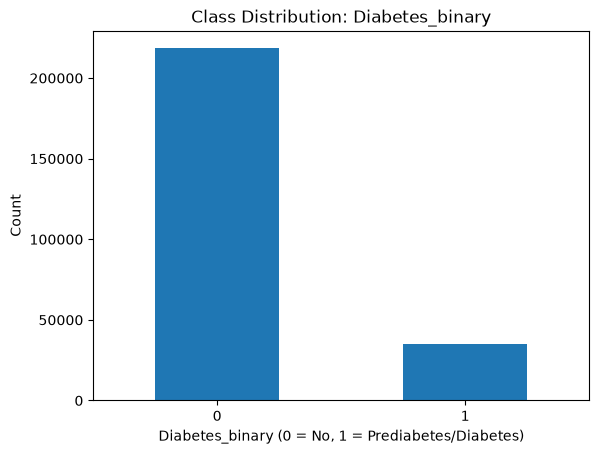

In [11]:
import matplotlib.pyplot as plt

df['Diabetes_binary'].value_counts().plot(kind='bar')
plt.title('Class Distribution: Diabetes_binary')
plt.xlabel('Diabetes_binary (0 = No, 1 = Prediabetes/Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()